<div style="background:linear-gradient(90deg,#1A2E4A 0%,#2E5E9B 100%);color:white;padding:20px 26px;border-radius:12px;">
<span style="font-size:12px;letter-spacing:3px;color:#D6E8F7;">CURSO IA APLICADA A CIENCIA DE MATERIALES &nbsp;·&nbsp; DÍA 5 · SOLUCIÓN DEL INSTRUCTOR</span><br>
<span style="font-size:26px;font-weight:700;">🛠️ Brief B: Recubrimiento PVD · solución completa</span><br>
<span style="font-size:14px;color:#D6E8F7;">35 experimentos históricos, 5 propuestas con predicción e incertidumbre</span>
</div>

**Para el instructor.** Es una de muchas soluciones válidas. Sirve como vara de comparación
durante el checkpoint y las presentaciones, no como respuesta única.

**Idea central de esta solución:** el histórico no son 35 puntos al azar. Es un diseño de
experimentos (Día 4) con réplicas. Eso nos da el ruido de medición, que es la vara para saber
qué diferencias importan. Después: GP para dureza **y** para CoF, validación leave-one-out
contra líneas base, y un lote de 5 que mezcla explotar, explorar y un control.

| Criterio de la rúbrica | Dónde se responde |
|---|---|
| Razonamiento del pipeline (40 %) | Secciones 1 y 2: estructura del histórico, ruido, por qué GP, cómo se valida con 35 puntos, qué se hace con el CoF |
| Calidad del resultado (25 %) | Sección 2: GP frente a líneas base, calibración de la incertidumbre. Sección 3: lote sin repetir condiciones |
| Comunicación al cliente (25 %) | Sección 4: dos figuras y un párrafo para el jefe de planta |
| Limitaciones (10 %) | Sección 5 |

In [1]:
import matplotlib.pyplot as plt
from cycler import cycler
AZUL, NARANJA, PURPURA, VERDE = "#2E5E9B", "#D96F0F", "#B0509E", "#2F9E44"
TINTA, GRIS = "#1A2E4A", "#8A94A3"
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=[AZUL, NARANJA, PURPURA, VERDE]),
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": TINTA, "axes.labelcolor": TINTA, "text.color": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "lines.linewidth": 2.0, "figure.dpi": 105, "legend.frameon": False,
})

In [2]:
import warnings
import numpy as np
import pandas as pd
import torch
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from botorch.models import SingleTaskGP, ModelListGP
from botorch.models.transforms import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.acquisition.objective import GenericMCObjective
from botorch.optim import optimize_acqf
warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0)
from pathlib import Path
def encontrar_datos() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents[:3]]:
        if (base / "datos").is_dir():
            return base / "datos"
    raise FileNotFoundError("No encuentro la carpeta datos/")
DATOS = encontrar_datos()
df = pd.read_csv(DATOS / "brief_B_recubrimiento.csv")
PROC = ["T_sustrato", "P_N2", "bias_voltaje", "fraccion_Ti", "potencia_kW"]
print(f"Histórico: {len(df)} experimentos")
df.describe().loc[["min", "max"]].round(2)

Histórico: 35 experimentos


,exp_id,T_sustrato,P_N2,bias_voltaje,fraccion_Ti,potencia_kW,dureza_HV,CoF
min,1.0,300.0,0.3,-200.0,0.3,2.0,1371.0,0.37
max,35.0,550.0,1.5,-50.0,0.8,6.0,3170.0,0.52


<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 1. EDA: ¿qué hizo la planta y cuánto ruido hay?</b></div>

### Hallazgo 1: el histórico ya es un diseño de experimentos

In [3]:
bloques = [(1, 8, "Factorial 2³ en T, P_N2 y bias (Ti 0.55, 4.2 kW)"),
           (9, 11, "Tres réplicas del punto central"),
           (12, 13, "T baja y alta en el centro"),
           (14, 19, "Un factor a la vez: fracción de Ti"),
           (20, 23, "Un factor a la vez: potencia"),
           (24, 28, "Ajuste fino cerca del mejor punto"),
           (29, 35, "Puntos dispersos")]
filas = []
for a, b, d in bloques:
    sub = df[(df.exp_id >= a) & (df.exp_id <= b)]
    filas.append({"experimentos": f"{a}–{b}", "qué son": d, "dureza HV": f"{sub.dureza_HV.min()}–{sub.dureza_HV.max()}",
                  "CoF": f"{sub.CoF.min():.3f}–{sub.CoF.max():.3f}"})
pd.DataFrame(filas)

,experimentos,qué son,dureza HV,CoF
0,1–8,"Factorial 2³ en T, P_N2 y bias (Ti 0.55, 4.2 kW)",1555–2554,0.385–0.518
1,9–11,Tres réplicas del punto central,3031–3072,0.401–0.409
2,12–13,T baja y alta en el centro,2855–2877,0.433–0.470
3,14–19,Un factor a la vez: fracción de Ti,3080–3170,0.376–0.376
4,20–23,Un factor a la vez: potencia,2206–3046,0.376–0.377
5,24–28,Ajuste fino cerca del mejor punto,3143–3166,0.369–0.382
6,29–35,Puntos dispersos,1371–2591,0.416–0.464


La planta ya hizo un factorial, réplicas, barridos de un factor a la vez y un ajuste fino.
El mejor histórico ronda los **3170 HV** y hay 5 ensayos entre 3140 y 3170: la zona buena ya
está bastante explorada. Mejorar mucho más no es obvio, y la propuesta debe decirlo.

### Hallazgo 2: el ruido de medición es la vara

In [4]:
rep = df[df.exp_id.isin([9, 10, 11])]
ruido = rep.dureza_HV.std(ddof=1)
print(f"Réplicas 9–11 (mismas condiciones): {rep.dureza_HV.tolist()} HV")
print(f"Desviación estándar entre réplicas: {ruido:.0f} HV")
mejor = df.loc[df.dureza_HV.idxmax()]
print(f"Mejor histórico: experimento {int(mejor.exp_id)}, {mejor.dureza_HV:.0f} HV, CoF {mejor.CoF:.3f}")
cercanos = df[df.dureza_HV >= mejor.dureza_HV - 2 * ruido]
print(f"Experimentos a menos de 2σ del mejor: {cercanos.exp_id.tolist()}  (entre ellos no se puede decir cuál es mejor)")

Réplicas 9–11 (mismas condiciones): [3053, 3031, 3072] HV
Desviación estándar entre réplicas: 21 HV
Mejor histórico: experimento 16, 3170 HV, CoF 0.376
Experimentos a menos de 2σ del mejor: [15, 16, 17, 24, 25, 26, 27, 28]  (entre ellos no se puede decir cuál es mejor)


### Hallazgo 3: dureza y CoF dependen de cosas distintas

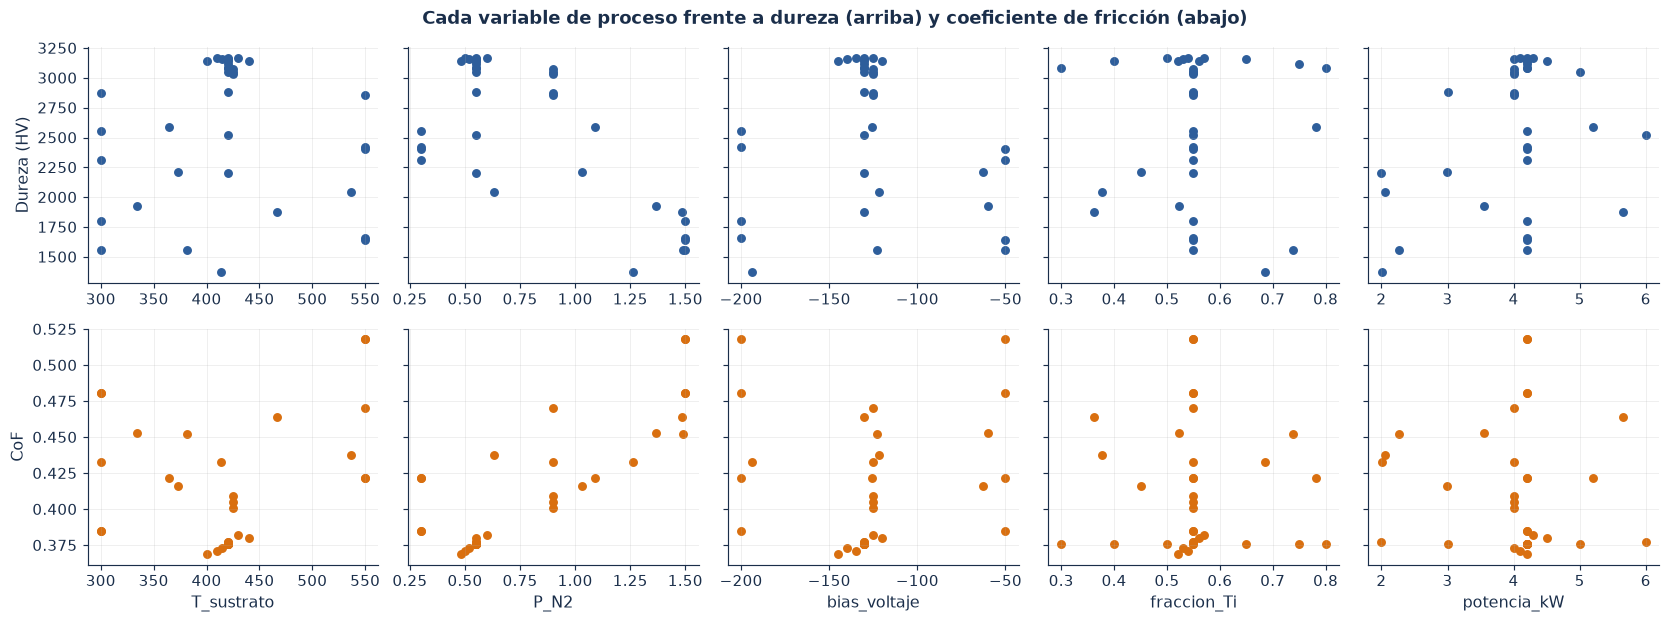

              dureza_HV   CoF
T_sustrato        -0.00  0.23
P_N2              -0.71  0.83
bias_voltaje      -0.07  0.08
fraccion_Ti       -0.02 -0.03
potencia_kW        0.33 -0.08


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey="row")
for k, col in enumerate(PROC):
    axes[0, k].scatter(df[col], df.dureza_HV, s=26, color=AZUL)
    axes[1, k].scatter(df[col], df.CoF, s=26, color=NARANJA)
    axes[1, k].set_xlabel(col)
axes[0, 0].set_ylabel("Dureza (HV)"); axes[1, 0].set_ylabel("CoF")
fig.suptitle("Cada variable de proceso frente a dureza (arriba) y coeficiente de fricción (abajo)", fontweight="bold")
plt.tight_layout(); plt.show()
print(df[PROC + ["dureza_HV", "CoF"]].corr().loc[PROC, ["dureza_HV", "CoF"]].round(2))

- La **dureza** cae con mucho N₂ y con poca potencia, y tiene un máximo en el centro de T: la
  respuesta es curva. Un modelo lineal no la va a capturar.
- El **CoF** depende sobre todo de P_N2 y de T, y casi nada de la fracción de Ti o de la
  potencia (en los barridos 14 a 23 el CoF no se mueve).
- Por eso el CoF no se puede ignorar: lo modelamos aparte y lo usamos como **restricción**.

<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 2. Modelo: GP con validación leave-one-out</b></div>

**Por qué un GP:** con 35 puntos en 5 variables, un GP interpola bien, da **incertidumbre**
(la necesitamos para decidir qué ensayar) y se integra con BoTorch.

**Cómo validar con 35 puntos:** un split 80/20 deja 7 puntos de prueba, demasiado ruidoso.
Usamos **leave-one-out**: 35 modelos, cada uno predice el punto que no vio. Y lo comparamos con
dos líneas base: predecir el promedio y una regresión lineal.

Las variables se escalan a [0, 1] con el rango histórico: así el GP compara longitudes de
correlación entre variables con unidades distintas.

In [6]:
X = df[PROC].values.astype(float)
LO, HI = X.min(0), X.max(0)
escalar = lambda x: (x - LO) / (HI - LO)
desescalar = lambda z: z * (HI - LO) + LO
Xn = torch.tensor(escalar(X), dtype=torch.double)
Y_hv = torch.tensor(df.dureza_HV.values, dtype=torch.double).unsqueeze(-1)
Y_cof = torch.tensor(df.CoF.values, dtype=torch.double).unsqueeze(-1)

def ajustar_gp(Xt, Yt):
    gp = SingleTaskGP(Xt, Yt, outcome_transform=Standardize(m=1))
    fit_gpytorch_mll(ExactMarginalLogLikelihood(gp.likelihood, gp))
    return gp

def loo(Y):
    medias, sds, lin, prom = [], [], [], []
    for i in range(len(Xn)):
        m = torch.arange(len(Xn)) != i
        gp = ajustar_gp(Xn[m], Y[m])
        with torch.no_grad():
            post = gp.posterior(Xn[[i]], observation_noise=True)   # incluye el ruido de medición
        medias.append(post.mean.item()); sds.append(post.variance.sqrt().item())
        lin.append(LinearRegression().fit(Xn[m].numpy(), Y[m].numpy().ravel()).predict(Xn[[i]].numpy())[0])
        prom.append(Y[m].mean().item())
    return np.array(medias), np.array(sds), np.array(lin), np.array(prom)

res = {}
for nombre, Y in [("dureza_HV", Y_hv), ("CoF", Y_cof)]:
    mu, sd, lin, prom = loo(Y)
    y = Y.numpy().ravel()
    res[nombre] = (mu, sd)
    dentro = (np.abs(mu - y) <= 2 * sd).mean()
    print(f"{nombre:10s}  MAE leave-one-out:  promedio {np.abs(prom - y).mean():7.3f} | lineal {np.abs(lin - y).mean():7.3f} | "
          f"GP {np.abs(mu - y).mean():7.3f}   (GP: {dentro:.0%} de los puntos dentro de ±2σ)")

dureza_HV   MAE leave-one-out:  promedio 533.857 | lineal 401.820 | GP  48.242   (GP: 97% de los puntos dentro de ±2σ)


CoF         MAE leave-one-out:  promedio   0.037 | lineal   0.022 | GP   0.001   (GP: 94% de los puntos dentro de ±2σ)


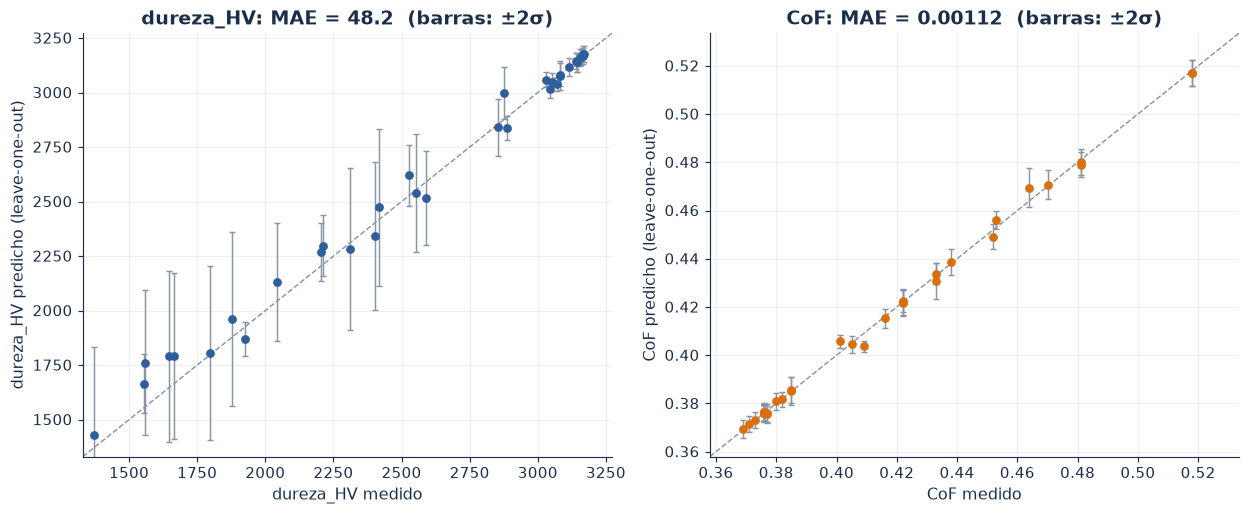

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, Y), color in zip(axes, [("dureza_HV", Y_hv), ("CoF", Y_cof)], [AZUL, NARANJA]):
    mu, sd = res[nombre]; y = Y.numpy().ravel()
    ax.errorbar(y, mu, yerr=2 * sd, fmt="o", ms=5, color=color, ecolor=GRIS, elinewidth=1, capsize=2)
    lim = [min(y.min(), mu.min()) * 0.97, max(y.max(), mu.max()) * 1.03]
    ax.plot(lim, lim, "--", color=GRIS, lw=1); ax.set(xlim=lim, ylim=lim)
    ax.set_xlabel(f"{nombre} medido"); ax.set_ylabel(f"{nombre} predicho (leave-one-out)")
    ax.set_title(f"{nombre}: MAE = {np.abs(mu - y).mean():.3g}  (barras: ±2σ)")
plt.tight_layout(); plt.show()

In [8]:
gp_hv, gp_cof = ajustar_gp(Xn, Y_hv), ajustar_gp(Xn, Y_cof)
ls = pd.DataFrame({"dureza_HV": gp_hv.covar_module.lengthscale.detach().numpy().ravel(),
                   "CoF": gp_cof.covar_module.lengthscale.detach().numpy().ravel()}, index=PROC)
print("Longitud de correlación del GP (escala 0 a 1). Más corta = la salida cambia más rápido con esa variable:")
ls.round(2)

Longitud de correlación del GP (escala 0 a 1). Más corta = la salida cambia más rápido con esa variable:


,dureza_HV,CoF
T_sustrato,1.48,0.65
P_N2,0.96,1.12
bias_voltaje,0.83,17.62
fraccion_Ti,1.94,19.73
potencia_kW,0.68,18.65


**Lectura:**

- El GP gana con claridad a las dos líneas base en dureza: la respuesta es curva y el GP la sigue.
- La incertidumbre está razonablemente **calibrada** si cerca del 95 % de los puntos cae dentro de ±2σ.
- Las longitudes de correlación confirman el EDA: la dureza es sensible a varias variables, y el
  CoF casi no depende de la fracción de Ti ni de la potencia (longitudes largas).

<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 3. Resultado: las próximas 5 condiciones</b></div>

**Supuesto que hay que declarar al cliente:** "CoF bajo control" lo traducimos como
**CoF ≤ 0.40**. Los mejores ensayos históricos están en 0.37 a 0.38. Si el cliente da otro
límite, se cambia una línea.

**El lote de 5:**

1. **Un control:** repetir el mejor histórico (experimento 16). Cuesta un turno, pero detecta si
   la cámara o el blanco cambiaron desde el histórico (deriva) y da otra réplica del ruido.
2. **Explotación, óptimo del modelo:** el punto que maximiza *qLogNoisyExpectedImprovement* con
   el CoF como restricción.
3. **Explotación, variante:** la condición con mayor probabilidad de superar al mejor histórico
   (y de cumplir el CoF) que esté a una distancia mínima de las anteriores. Sin esa distancia, el
   optimizador propone casi el mismo punto otra vez y se pierde un turno.
4. y 5. **Exploración útil:** condiciones lejos de todo lo ensayado, con la mejor dureza
   optimista (media + 2σ) y probable cumplimiento del CoF. El histórico movió la fracción de Ti y
   la potencia **una a la vez**: las combinaciones nunca se probaron.

Las predicciones incluyen el ruido de medición: dicen lo que la planta va a **medir**, no solo
lo que el modelo cree del promedio. Todo dentro del rango histórico: no extrapolamos.

In [9]:
LIM_COF = 0.40
mejor_hist = df.dureza_HV.max()
i_mejor = int(df.dureza_HV.values.argmax())
modelo = ModelListGP(gp_hv, gp_cof)
limites = torch.stack([torch.zeros(5), torch.ones(5)]).double()

def predecir(Z):
    Z = Z.unsqueeze(-2)        # un punto por lote: solo varianzas, sin la matriz de covarianza completa
    with torch.no_grad():
        ph, pc = gp_hv.posterior(Z, observation_noise=True), gp_cof.posterior(Z, observation_noise=True)
    return (ph.mean.numpy().ravel(), ph.variance.sqrt().numpy().ravel(),
            pc.mean.numpy().ravel(), pc.variance.sqrt().numpy().ravel())

# 1) control
elegidos = [Xn[[i_mejor]]]
# 2) óptimo del modelo con la restricción de CoF
acq = qLogNoisyExpectedImprovement(
    model=modelo, X_baseline=Xn,
    objective=GenericMCObjective(lambda Z, X=None: Z[..., 0]),
    constraints=[lambda Z: Z[..., 1] - LIM_COF])
x_opt, _ = optimize_acqf(acq, bounds=limites, q=1, num_restarts=20, raw_samples=1024)
elegidos.append(x_opt)

# candidatos: al azar en todo el rango + muchos cerca del mejor histórico
cand = torch.cat([torch.rand(40000, 5, dtype=torch.double),
                  (Xn[[i_mejor]] + 0.12 * torch.randn(20000, 5, dtype=torch.double)).clamp(0, 1)])
mh, sh, mc, sc = predecir(cand)
p_cof = norm.cdf((LIM_COF - mc) / sc)
p_mejor = 1 - norm.cdf((mejor_hist - mh) / sh)
dist_hist = torch.cdist(cand, Xn).min(1).values.numpy()
lejos_de = lambda r: torch.cdist(cand, torch.cat(elegidos)).min(1).values.numpy() > r

# 3) variante de explotación, a distancia mínima 0.15 de lo ya elegido
puntaje = p_mejor * p_cof
puntaje[~lejos_de(0.15)] = -1
elegidos.append(cand[[int(puntaje.argmax())]])
# 4 y 5) exploración útil: lejos del histórico, optimista en dureza y probable en CoF
for _ in range(2):
    puntaje = (mh + 2 * sh) * (p_cof >= 0.8)
    puntaje[~(lejos_de(0.25) & (dist_hist >= 0.25))] = -1
    elegidos.append(cand[[int(puntaje.argmax())]])

orden = [1, 2, 3, 4, 0]                     # control al final de la tabla
Z = torch.cat([elegidos[k] for k in orden])
# redondear a lo que la planta puede fijar y volver a predecir en esos valores
paso = np.array([5, 0.01, 5, 0.01, 0.1])
reales = np.round(desescalar(Z.numpy()) / paso) * paso
Z = torch.tensor(escalar(reales), dtype=torch.double)
mh, sh, mc, sc = predecir(Z)
tabla = pd.DataFrame(reales, columns=PROC)
tabla.insert(0, "tipo", ["explotación: óptimo del modelo", "explotación: variante", "exploración", "exploración", "control: repite el exp. 16"])
tabla["HV_pred"] = mh.round(0).astype(int)
tabla["±σ"] = sh.round(0).astype(int)
tabla["P(HV > mejor)"] = (1 - norm.cdf((mejor_hist - mh) / sh)).round(2)
tabla["CoF_pred"] = mc.round(3)
tabla[f"P(CoF ≤ {LIM_COF})"] = norm.cdf((LIM_COF - mc) / sc).round(2)
d = torch.cdist(Z, Z); d.fill_diagonal_(9)
print(f"Distancia mínima entre propuestas (escala 0 a 1): {d.min():.2f}")
print(f"Mejor histórico: {mejor_hist} HV · ruido entre réplicas: {ruido:.0f} HV")
tabla

Distancia mínima entre propuestas (escala 0 a 1): 0.11
Mejor histórico: 3170 HV · ruido entre réplicas: 21 HV


,tipo,T_sustrato,P_N2,bias_voltaje,fraccion_Ti,potencia_kW,HV_pred,±σ,P(HV > mejor),CoF_pred,P(CoF ≤ 0.4)
0,explotación: óptimo del modelo,420.0,0.60,-130.0,0.55,4.2,3182,17,0.76,0.380,1.0
1,explotación: variante,425.0,0.56,-130.0,0.63,4.2,3170,17,0.51,0.378,1.0
2,exploración,365.0,0.67,-130.0,0.46,4.1,3123,21,0.01,0.387,1.0
3,exploración,350.0,0.55,-130.0,0.61,4.2,3114,23,0.01,0.382,1.0
4,control: repite el exp. 16,420.0,0.55,-130.0,0.50,4.2,3176,17,0.63,0.376,1.0


**Cómo se defiende el lote:**

- **El hallazgo principal es que la planta ya está cerca del óptimo** de la zona que exploró. El
  modelo predice como mucho unas decenas de HV por encima del mejor histórico, del orden del
  ruido de medición. Decirlo claramente es parte de un buen resultado: evita prometer lo que no hay.
- Por eso el lote no apuesta todo a explotar: dos ensayos confirman la zona óptima (y su
  reproducibilidad), dos exploran combinaciones nunca probadas y uno controla la deriva.
- Las cinco condiciones son distintas entre sí y todas cumplen el CoF con alta probabilidad.
- Una mejora pequeña hay que confirmarla con una réplica antes de cambiar la receta de la planta.
- Si el control no da unos 3170 HV, el problema es la planta, no las condiciones nuevas.

<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 4. Comunicación al jefe de planta</b></div>

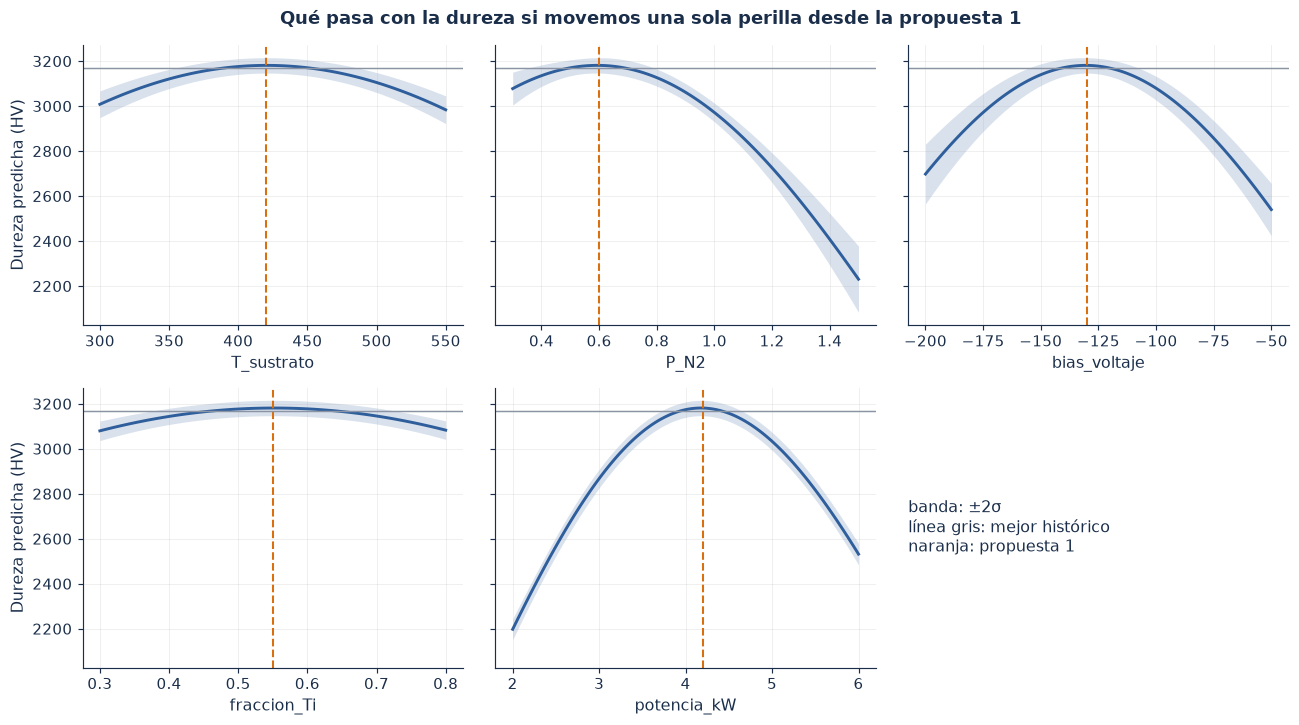

In [10]:
ref = Z[0].clone()
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7), sharey=True)
axes[1, 2].axis("off"); axes = axes.ravel()
malla = torch.linspace(0, 1, 120, dtype=torch.double)
for k, col in enumerate(PROC):
    Zs = ref.repeat(len(malla), 1); Zs[:, k] = malla
    m, s, _, _ = predecir(Zs)
    xr = desescalar(Zs.numpy())[:, k]
    axes[k].fill_between(xr, m - 2 * s, m + 2 * s, color=AZUL, alpha=0.18, lw=0)
    axes[k].plot(xr, m, color=AZUL)
    axes[k].axvline(reales[0, k], color=NARANJA, ls="--", lw=1.4)
    axes[k].axhline(mejor_hist, color=GRIS, lw=1)
    axes[k].set_xlabel(col)
axes[0].set_ylabel("Dureza predicha (HV)"); axes[3].set_ylabel("Dureza predicha (HV)")
axes[5].text(0.0, 0.5, "banda: ±2σ\nlínea gris: mejor histórico\nnaranja: propuesta 1", transform=axes[5].transAxes, fontsize=11, color=TINTA, va="center")
fig.suptitle("Qué pasa con la dureza si movemos una sola perilla desde la propuesta 1", fontweight="bold")
plt.tight_layout(); plt.show()

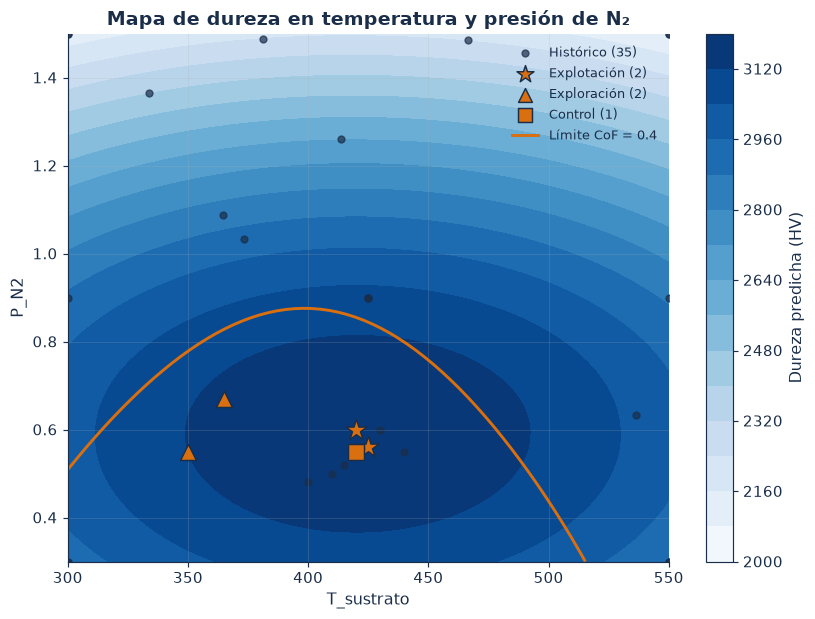

Ojo: el mapa fija las otras tres variables en la propuesta 1; los puntos históricos se muestran proyectados.


In [11]:
# mapa en temperatura y presión de N2: ahí se separan las propuestas y ahí actúa el límite de CoF
i, j = PROC.index("T_sustrato"), PROC.index("P_N2")
g = torch.linspace(0, 1, 70, dtype=torch.double)
A, B = torch.meshgrid(g, g, indexing="ij")
Zg = ref.repeat(A.numel(), 1); Zg[:, i] = A.ravel(); Zg[:, j] = B.ravel()
m, _, mc_g, _ = predecir(Zg)
xa, xb = desescalar(Zg.numpy())[:, i].reshape(A.shape), desescalar(Zg.numpy())[:, j].reshape(A.shape)
fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(xa, xb, m.reshape(A.shape), levels=14, cmap="Blues")
plt.colorbar(cs, label="Dureza predicha (HV)")
ax.contour(xa, xb, mc_g.reshape(A.shape), levels=[LIM_COF], colors=[NARANJA], linewidths=2)
ax.scatter(df[PROC[i]], df[PROC[j]], s=22, color=TINTA, alpha=0.7, label="Histórico (35)")
marcas = ["*", "*", "^", "^", "s"]
for r, mk, t in zip(reales, marcas, tabla.tipo):
    ax.scatter(r[i], r[j], marker=mk, s=230 if mk == "*" else 120, color=NARANJA, edgecolor=TINTA, zorder=3)
ax.scatter([], [], marker="*", s=150, color=NARANJA, edgecolor=TINTA, label="Explotación (2)")
ax.scatter([], [], marker="^", s=90, color=NARANJA, edgecolor=TINTA, label="Exploración (2)")
ax.scatter([], [], marker="s", s=80, color=NARANJA, edgecolor=TINTA, label="Control (1)")
ax.plot([], [], color=NARANJA, lw=2, label=f"Límite CoF = {LIM_COF}")
ax.set(xlabel=PROC[i], ylabel=PROC[j], title="Mapa de dureza en temperatura y presión de N₂")
ax.legend(loc="best", fontsize=9); plt.tight_layout(); plt.show()
print("Ojo: el mapa fija las otras tres variables en la propuesta 1; los puntos históricos se muestran proyectados.")

In [12]:
mae_hv = np.abs(res["dureza_HV"][0] - df.dureza_HV.values).mean()
print(f"""PÁRRAFO PARA EL JEFE DE PLANTA

Con los 35 ensayos de la planta armamos un modelo que predice la dureza con un error típico
de {mae_hv:.0f} HV y que además dice cuándo no está seguro. La conclusión principal es que la
planta ya opera cerca de la mejor dureza posible dentro de las condiciones que ha probado: el
modelo no espera mejoras grandes ahí. Proponemos 5 ensayos (5 turnos, unos $2500): dos en la
zona óptima para confirmarla, dos que combinan perillas que nunca se movieron juntas (por si hay
algo mejor que el histórico no vio) y una repetición del mejor ensayo ({mejor_hist} HV) para
verificar que la planta no ha cambiado. Todas mantienen la fricción por debajo de {LIM_COF}.
Cualquier mejora menor a unos {2 * ruido:.0f} HV es ruido de medición y debe confirmarse con
una réplica antes de cambiar la receta.""")

PÁRRAFO PARA EL JEFE DE PLANTA

Con los 35 ensayos de la planta armamos un modelo que predice la dureza con un error típico
de 48 HV y que además dice cuándo no está seguro. La conclusión principal es que la
planta ya opera cerca de la mejor dureza posible dentro de las condiciones que ha probado: el
modelo no espera mejoras grandes ahí. Proponemos 5 ensayos (5 turnos, unos $2500): dos en la
zona óptima para confirmarla, dos que combinan perillas que nunca se movieron juntas (por si hay
algo mejor que el histórico no vio) y una repetición del mejor ensayo (3170 HV) para
verificar que la planta no ha cambiado. Todas mantienen la fricción por debajo de 0.4.
Cualquier mejora menor a unos 41 HV es ruido de medición y debe confirmarse con
una réplica antes de cambiar la receta.


<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 5. Limitaciones y próximos pasos</b></div>

- **35 puntos en 5 dimensiones es poco.** El GP interpola; fuera del rango histórico sus
  predicciones no son confiables, por eso no extrapolamos.
- **El límite de CoF es un supuesto nuestro (0.40).** Hay que confirmarlo con el cliente.
- **Ruido:** las réplicas varían unos 20 HV. Diferencias menores entre candidatos no son significativas.
- **Deriva de proceso:** si cambió el blanco de sputtering, la cámara o el proveedor de gas, el
  modelo hereda el sesgo del histórico. El punto de control lo detecta.
- **Otras propiedades:** adherencia, tensiones residuales y desgaste no están en los datos.
  Una condición muy dura puede delaminarse.
- **Próximo paso:** correr los 5, agregarlos al histórico, reentrenar y proponer el siguiente
  lote. Ese ciclo es la optimización bayesiana del Día 4.
- **Uso de asistentes de IA:** si se usaron para escribir código, declararlo y explicar qué se verificó a mano.